# 16.9 Attention 中間矩陣為何佔空間？


長度T的注意力要比較每個Query與每個Key，分數表有T×T格。T由4增到8，格數由16變64；若T=8192，一個頭就有約6711萬格。即使不增加模型權重，保存分數與softmax權重的中間表也可能很占記憶體。能否分塊讀Key、Value，一邊計算一邊累積結果，不把整張表保存在GPU容量較大的顯示記憶體裡？

[SDPA](https://birdhackor.github.io/tiny-perceptron-vlm/16.8.html)算的是同一套分數、softmax和Value加權和。FlashAttention把這些工作分塊安排，減少中間資料搬移；我們要讓分塊後仍得到原來的加權答案，不是丟掉候選位置。這裡的log是自然對數，exp是自然指數，兩者互逆：`exp(log(1))=1`、`exp(log(2))=2`、`exp(log(4))=4`，其中log(1)=0、log(2)約0.6931、log(4)約1.3863。程式用`math.log`計算自然對數、`torch.exp`計算自然指數。

先看一個Query、三個候選：分數 `[0,log(2),log(4)]`，Value為 `[10,20,30]`。取指數得到 `[1,2,4]`，加權結果 `(10+40+120)/7=24.2857`。我們要在兩塊內得到同一數字。每個分數減去同一個值，再取指數，相當於所有權重乘上同一係數；例如都減log(4)，權重變成 `[0.25,0.5,1]`。分子170與分母7都乘0.25，變成42.5與1.75，相除的比例不變。一般規則是 `exp(a-b)=exp(a)/exp(b)`，所以 `exp(log(2)-log(4))=2/4=0.5`。

softmax為避免指數太大，會減去本列最大分數。第一塊只有前兩項，最大是log2，指數權重 `[0.5,1]`，分母1.5，加權分子25。第二塊帶來log4，最大值改了；舊分子、分母都要乘 `exp(log2-log4)=0.5`，再加新權重1與新Value30，得到分母1.75、分子42.5。兩者相除仍24.2857。只保留分母或忘記同步縮放分子，都會算錯。

圖中的分子是尚未除以總權重的加權總和，箭頭是處理先後。第二框的「×0.5」把舊統計改到新最大值的基準，再加入第二塊，並不是給第二塊額外折扣。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

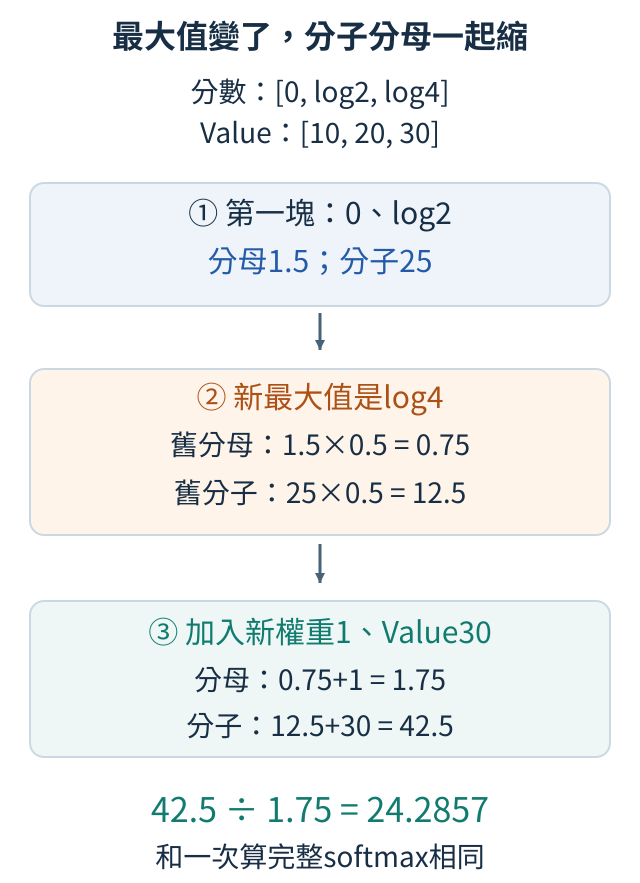

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-16-online-softmax.svg")))

In [3]:
import math
import torch

scores = torch.tensor([0.0, math.log(2), math.log(4)])
values = torch.tensor([10.0, 20.0, 30.0])
m = torch.tensor(float("-inf"))
denominator = torch.tensor(0.0)
numerator = torch.tensor(0.0)
for start in range(0, 3, 2):
    block = scores[start : start + 2]
    new_m = torch.maximum(m, block.max())
    factor = torch.exp(m - new_m)
    weight = torch.exp(block - new_m)
    denominator = denominator * factor + weight.sum()
    numerator = numerator * factor + (weight * values[start : start + 2]).sum()
    m = new_m
    print("分母/分子", denominator.item(), numerator.item())
print("分塊結果", round((numerator / denominator).item(), 4))
print("完整結果", round((scores.softmax(0) * values).sum().item(), 4))

分母/分子 1.5 25.0
分母/分子 1.75 42.5
分塊結果 24.2857
完整結果 24.2857


初始最大值是負無窮大，第一次縮放係數為零，沒有舊貢獻。兩輪印出1.5/25與1.75/42.5，最後兩行都是24.2857。`range(0,3,2)`每次讀最多兩項，最後只有一項；沒有保存完整softmax權重。這種依序更新統計的技巧稱online softmax，online指逐塊處理，不是連上網路。

這個CPU標量例子只示範數學。實際FlashAttention還將Query、Key、Value分塊放入GPU較快的片上記憶體，安排專用運算與反向重算；Python迴圈本身不具這些速度或訓練記憶體收益。要驗證收益，應在相容硬體使用對應SDPA後端，再量測時間與最高記憶體占用。

論文所用的HBM是high-bandwidth memory（高頻寬記憶體），屬於GPU容量較大的顯示記憶體；前文的片上記憶體則位在運算晶片內，容量較小但更快。分塊讓一小份資料留在片上反覆計算，減少與較大顯示記憶體之間的搬移。分塊、統計合併與少讀寫HBM的原始推導見[FlashAttention第3.1節、Algorithm 1與Theorem 1，第3.2節Theorem 2](https://arxiv.org/pdf/2205.14135v2)。其中exact表示完整注意力的數學問題，並不保證不同運算順序的浮點輸出逐bit一致；上節實報仍保留數值誤差。

資源收益可由指定形狀的核心測量看出：L4上，FP16的Q/K/V形狀固定為`[2,4,512,32]`，已核驗使用CUDA Flash。只向前時，手寫／Flash中位數為0.513／0.076毫秒，配置器新增峰值為24.25／0.267 MiB。這些數字量的是注意力核心的讀寫與暫存，沒有增加模型的訓練長度或長文理解能力。兩條路還有相同已配置起點，完整總峰值、反傳、低精度誤差與後端條件在選讀，不用新增量的倍數代替整張GPU用量。

練習把每塊大小由2改成1：`range(0, 3, 2)`最後的2，以及兩處切片`scores[start : start + 2]`、`values[start : start + 2]`裡的2，都一起改成1。迴圈步長與每次讀取數量要一致，才不會重複讀取候選。先預測中間統計出現三輪，但最終仍24.2857，再執行核對。分塊方式應影響儲存與工作安排，不能改變所計算的加權平均。

<details>
<summary>選讀：實際CUDA後端、誤差與峰值範圍</summary>

efficiency組的FP32 SDPA實際用了memory-efficient，所以上節0.644毫秒的差不能稱為Flash加速。[NVIDIA硬體表](https://developer.nvidia.com/cuda-gpus)列L4 compute capability 8.9；compute capability是GPU運算能力的版本號，這裡的SM8.x按8.x版本分類，8.9屬於其中。L4滿足[PyTorch 2.14.1官方選擇程式](https://github.com/pytorch/pytorch/blob/5c4886908584029761b579af026dcfb627c84070/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp#L413)的SM範圍；同檔的`check_dtypes_flash_attention`對SM8.x要求FP16／BF16，還要檢查安裝的PyTorch是否編入Flash支援，以及形狀、遮罩等條件。硬體名稱或API名字本身都不能替代當次後端核驗。

上節的額外Flash補驗已確認兩種低精度的真正CUDA前向與反傳，現在才讀成本。每條路線先暖機三次，再量九次、在兩側等待GPU完成，取中位數；記憶體單位MiB是1024×1024 bytes，也就是1,048,576 bytes。下面只是固定Q/K/V注意力核心，沒有語言模型、任務loss或更新器：

| 精度與運算範圍 | 手寫毫秒 | 強制Flash毫秒 | 手寫新增峰值MiB | Flash新增峰值MiB |
| --- | ---: | ---: | ---: | ---: |
| FP16，只向前 | 0.513 | 0.076 | 24.25 | 0.267 |
| FP16，向前＋Q/K/V反傳 | 1.689 | 0.503 | 32.75 | 2.032 |
| BF16，只向前 | 0.516 | 0.071 | 24.25 | 0.267 |
| BF16，向前＋Q/K/V反傳 | 1.502 | 0.458 | 32.75 | 2.032 |

圖把FP16的記憶體起點也畫出來：灰色是每條路線暖機後已配置的65.00MiB，彩色才是呼叫期間增加的峰值。反傳路線總峰值由97.75降到約67.03MiB；不能只把新增32.75與2.032相比，就宣稱整張GPU少用了同樣倍數的記憶體。


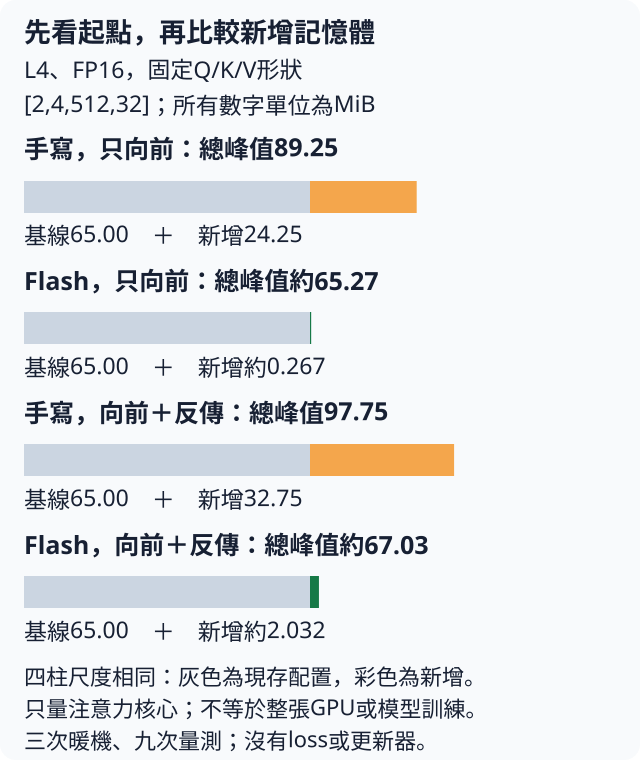

In [4]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/flash_allocated_memory.svg")))

這些是PyTorch追蹤的CUDA已配置記憶體，包含當時現存的張量與工作空間；不是整張顯示卡用量，也不含尚未使用的配置器保留區或驅動配置。只向前時停用梯度；向前加反傳包含供反傳使用的計算圖（運算關係）、保存值、暫存與Q/K/V梯度。固定輸入建立、數值核對和profiler都在量測區間外。這次核心較快、新增配置較少，但沒有量整個模型訓練加速或品質；若改長度、頭數、dtype與遮罩，需重新核驗。實際數值、CUDA wheel、driver、每次時間與峰值在[完整補驗報告](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/flash_probe.json)，重跑方法見[T.8](https://birdhackor.github.io/tiny-perceptron-vlm/training.html#T.8)。

</details>
